In [1]:
#!/usr/bin/env python3
# train_FG_long_k_fixed.py
# Fixed: removed undefined k_map usage and removed printing of model parameter count.
# Convert wide (ETA, F1..F12, G1..G12) -> long dataset with mapping k->(Ri,M)
# Train NN to predict (Fval,Gval) from inputs (Ri, M, Eta, k).
# Optional: you can later extend pde_residuals(...) and set USE_PDE=True for PINN.

import os, time, json
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split

# ---------------- User settings ----------------
DATA_PATH = "Grad-3Ec-Merged.csv"   # your CSV
OUT_DIR = "Grad-3Ec-pinn-results"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# F, G -> (Ri,M) as you described
Ec_map = {
    1: (1, 0.01), 2: (1, 0.05), 3: (1, 0.09)
}

"Extract Data.ipynb"
# training hyperparams (tune)
SEED = 42
N_EPOCHS = 5000
BATCH_SIZE = 128
LR = 2e-3
ONECYCLE_MAX_LR = 8e-3
GRAD_CLIP = 5.0
LBFGS_ITERS = 200
EARLY_STOPPING_PATIENCE = 1000
PRINT_EVERY = 100

USE_PDE = True   # set True only after you implement pde_residuals()
# ------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED); torch.manual_seed(SEED)

In [2]:
# ---------------- Load CSV and build long dataset ----------------
df_w = pd.read_csv(DATA_PATH)
print("Loaded CSV:", DATA_PATH, "shape:", df_w.shape)
print("Columns:", df_w.columns.tolist()[:20])

# find ETA column
eta_col = next((c for c in df_w.columns if c.strip().lower()=='eta' or 'eta' in c.lower()), None)
if eta_col is None:
    raise RuntimeError("ETA column not found in CSV.")

# check F/G columns exist
Ec_cols = [f"Ec{i}" for i in range(1,4)]
#G_cols = [f"G{i}" for i in range(1,7)]
for c in Ec_cols: #+G_cols:
    if c not in df_w.columns:
        raise RuntimeError(f"Column {c} not found in CSV.")

# Build long records: for each k create rows with assigned Ri,M
records = []
n_eta = df_w.shape[0]
for k in range(1,4):
    xi, ec  = Ec_map[k]
    Eccol = f"Ec{k}" #; Gcol = f"G{k}"
    for i in range(n_eta):
        records.append({
            "Xi": xi,
            "Ec": ec,
            "Eta": float(df_w.iloc[i][eta_col]),
            "k": float(k),  # kept only for grouping, NOT used as model input,           # include k as numeric (we'll normalize)
            "Ecval": float(df_w.iloc[i][Eccol])
        })
df = pd.DataFrame.from_records(records)
print("Built long dataframe shape:", df.shape)
df.to_csv(os.path.join(OUT_DIR,"Ec_long_raw.csv"), index=False)

Loaded CSV: Grad-3Ec-Merged.csv shape: (252, 4)
Columns: ['ETA', 'Ec1', 'Ec2', 'Ec3']
Built long dataframe shape: (756, 5)


In [3]:
# ---------------- Prepare model inputs/outputs ----------------
# Inputs: [Xi, Ec, Eta]  (k removed from model inputs) -> Outputs: [Ecval]
X = df[["Xi","Ec","Eta"]].values.astype(np.float32)
Y = df[["Ecval"]].values.astype(np.float32)

# Normalize inputs per-column (important)
X_mean = X.mean(axis=0); X_std = X.std(axis=0) + 1e-12
Y_mean = Y.mean(axis=0); Y_std = Y.std(axis=0) + 1e-12
Xn = (X - X_mean)/X_std
Yn = (Y - Y_mean)/Y_std

# Train/val/test split (stratify by (Xi,Ec) combos so each combo appears)
df["combo"] = df["Xi"].astype(str) + "_" + df["Ec"].astype(str)
idx = np.arange(Xn.shape[0])
train_idx, test_idx = train_test_split(idx, test_size=0.18, random_state=SEED, stratify=df['combo'])
# from test split further into val/test
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=SEED, stratify=df['combo'].iloc[test_idx])

X_train = Xn[train_idx]; Y_train = Yn[train_idx]
X_val   = Xn[val_idx];   Y_val   = Yn[val_idx]
X_test  = Xn[test_idx];  Y_test  = Yn[test_idx]

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

# Convert to torch
device = DEVICE
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_val_t   = torch.tensor(X_val, dtype=torch.float32, device=device)
Y_val_t   = torch.tensor(Y_val, dtype=torch.float32, device=device)
X_all_t   = torch.tensor(Xn, dtype=torch.float32, device=device)  # for LBFGS final refine / full predictions

Train/Val/Test sizes: 619 68 69


In [4]:
def pde_residual_Ec(model, xb):
    """
    Physics residual for Grad-3Ec energy equation
    xb = [Xi, Ec, Eta] (normalized)
    """

    xb.requires_grad_(True)

    # Network output: theta(eta)
    theta = model(xb)

    # First derivative dθ/dη
    grad_theta = torch.autograd.grad(
        theta, xb,
        grad_outputs=torch.ones_like(theta),
        retain_graph=True,
        create_graph=True
    )[0]

    theta_eta = grad_theta[:, 2:3]

    # Second derivative d²θ/dη²
    grad2_theta = torch.autograd.grad(
        theta_eta, xb,
        grad_outputs=torch.ones_like(theta_eta),
        retain_graph=True,
        create_graph=True
    )[0]

    theta_eta2 = grad2_theta[:, 2:3]

    # Parameters
    Xi = xb[:, 0:1]
    M  = xb[:, 1:2]

    # ---- Coefficients (from your notes, reduced form) ----
    a = 1.0 + Xi                     # convection term
    b = M + Xi**2                    # magnetic + buoyancy coupling

    # Energy equation residual
    residual = theta_eta2 + a * theta_eta + b * theta

    return residual


In [5]:
def loss_function(model, data_loss, bc_loss, x_pde, t_pde):
    loss = data_loss + bc_loss

    if USE_PDE:
        f_pde = pde_residual_Ec(model, x_pde, t_pde)
        pde_loss = torch.mean(f_pde**2)
        loss += pde_loss

    return loss


In [6]:
def physics_loss(model, xb):
    r = pde_residual_Ec(model, xb)
    return torch.mean(r**2)


In [7]:
def bc_loss(model, xb):
    """
    Boundary conditions for energy equation:
    theta(0) = 1
    theta(inf) = 0
    """

    eta = xb[:, 2:3]
    theta = model(xb)

    # ---- wall: eta = 0 ----
    # normalized eta ≈ 0 → use a small band
    mask_wall = torch.abs(eta) < 0.05
    if mask_wall.any():
        bc_wall = torch.mean((theta[mask_wall] - 1.0)**2)
    else:
        bc_wall = torch.tensor(0.0, device=xb.device)

    # ---- free stream: eta → ∞ ----
    mask_inf = eta > 1.5
    if mask_inf.any():
        bc_inf = torch.mean(theta[mask_inf]**2)
    else:
        bc_inf = torch.tensor(0.0, device=xb.device)

    return bc_wall + bc_inf


In [8]:
# ---------------- Model definition ----------------
class FGLongNet_3hidden(nn.Module):
    def __init__(self, in_dim=3, hidden=64, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU()
        )
        self.head = nn.Linear(hidden, out_dim)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        return self.head(self.net(x))


# 🔴 THIS LINE IS CRITICAL
model = FGLongNet_3hidden(in_dim=3, hidden=64, out_dim=1).to(device)


In [9]:
steps_per_epoch = max(
    1, int(np.ceil(X_train.shape[0] / float(BATCH_SIZE)))
)

total_steps = N_EPOCHS * steps_per_epoch


In [10]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-6)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=ONECYCLE_MAX_LR,
    total_steps=total_steps,
    pct_start=0.1,
    div_factor=10.0
)

mse = nn.MSELoss()


In [11]:
# ---------------- Training loop ----------------
best_val = 1e12; patience = 0
history = {'train':[], 'val':[]}
t0 = time.time()
for ep in range(1, N_EPOCHS+1):
    model.train()
    perm = np.random.permutation(X_train.shape[0])
    losses=[]
    for i in range(0, X_train.shape[0], BATCH_SIZE):
        idxb = perm[i:i+BATCH_SIZE]
        #xb = torch.tensor(X_train[idxb], dtype=torch.float32, device=device)
        xb = torch.tensor(X_train[idxb], dtype=torch.float32, device=device, requires_grad=True)

        yb = torch.tensor(Y_train[idxb], dtype=torch.float32, device=device)
        optimizer.zero_grad()
        pred = model(xb)
        
        loss_data = mse(pred, yb)

        if USE_PDE:
            loss_pde = physics_loss(model, xb)
            loss_bc  = bc_loss(model, xb)
            loss = loss_data + 0.00001*loss_pde + 0.00001*loss_bc

        else:
            loss = loss_data    

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        try:
            scheduler.step()
        except Exception:
            pass
        losses.append(loss.item())
    train_loss = float(np.mean(losses))
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t); val_loss = float(mse(val_pred, Y_val_t).item())
    history['train'].append(train_loss); history['val'].append(val_loss)
    if ep % PRINT_EVERY == 0 or ep==1:
        print(f"Epoch {ep}/{N_EPOCHS} train={train_loss:.3e} val={val_loss:.3e} lr={optimizer.param_groups[0]['lr']:.2e}")
    if val_loss < best_val:
        best_val = val_loss; patience = 0
        torch.save(model.state_dict(), os.path.join(OUT_DIR,"best_long.pt"))
    else:
        patience += 1
        if patience > EARLY_STOPPING_PATIENCE:
            print("Early stopping at epoch", ep); break

t1 = time.time()
print("Training done in {:.1f}s best_val={:.4e}".format(t1-t0, best_val))
model.load_state_dict(torch.load(os.path.join(OUT_DIR,"best_long.pt"), map_location=device))
model.eval()

Epoch 1/5000 train=1.020e+00 val=8.463e-01 lr=8.00e-04
Epoch 100/5000 train=7.100e-01 val=6.035e-01 lr=1.49e-03
Epoch 200/5000 train=4.801e-01 val=3.435e-01 lr=3.29e-03
Epoch 300/5000 train=3.847e-01 val=2.523e-01 lr=5.52e-03
Epoch 400/5000 train=3.746e-01 val=2.602e-01 lr=7.31e-03
Epoch 500/5000 train=3.202e-01 val=2.131e-01 lr=8.00e-03
Epoch 600/5000 train=2.831e-01 val=1.163e-01 lr=7.99e-03
Epoch 700/5000 train=2.588e-01 val=1.212e-01 lr=7.96e-03
Epoch 800/5000 train=2.647e-01 val=1.188e-01 lr=7.91e-03
Epoch 900/5000 train=2.653e-01 val=1.384e-01 lr=7.84e-03
Epoch 1000/5000 train=2.635e-01 val=1.421e-01 lr=7.76e-03
Epoch 1100/5000 train=2.556e-01 val=1.210e-01 lr=7.65e-03
Epoch 1200/5000 train=2.665e-01 val=1.276e-01 lr=7.53e-03
Epoch 1300/5000 train=2.561e-01 val=1.229e-01 lr=7.39e-03
Epoch 1400/5000 train=2.614e-01 val=1.209e-01 lr=7.24e-03
Epoch 1500/5000 train=2.527e-01 val=1.236e-01 lr=7.06e-03
Epoch 1600/5000 train=2.491e-01 val=1.188e-01 lr=6.88e-03
Epoch 1700/5000 train=2.50

FGLongNet_3hidden(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SiLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): SiLU()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): SiLU()
  )
  (head): Linear(in_features=64, out_features=1, bias=True)
)

In [12]:
# LBFGS refine (optional)
print("LBFGS refine...")
try:
    lbfgs = optim.LBFGS(model.parameters(), max_iter=LBFGS_ITERS)
    def closure():
        lbfgs.zero_grad()
        pred = model(X_all_t)
        loss = mse(pred, torch.tensor(Yn, dtype=torch.float32, device=device))
        loss.backward()
        return loss
    lbfgs.step(closure)
except Exception as e:
    print("LBFGS skipped/failed:", e)

# ---------------- Predict back to original scale ----------------
with torch.no_grad():
    Ypred_n = model(X_all_t).cpu().numpy()
Ypred = Ypred_n * Y_std + Y_mean   # invert normalization

# attach predictions to df and save
df['p_Ecval'] = Ypred[:,0]

out_csv = os.path.join(OUT_DIR, "Ec_long_preds.csv")
df.to_csv(out_csv, index=False)
print("Saved long-format predictions to:", out_csv)

# Compute RMSE overall and per combo and per k
df['err_Ec2'] = (df['p_Ecval'] - df['Ecval'])**2

rmse_overall = np.sqrt(df[['err_Ec2']].mean(axis=0))
print("Overall RMSE (Ec):", rmse_overall.tolist())

# per k RMSE
rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Ecval']-g['Ecval'])**2)))

rmse_df = pd.DataFrame({'k': rmse_k.index, 'rmse_Ec': rmse_k.values})
rmse_df.to_csv(os.path.join(OUT_DIR,"rmse_per_k.csv"), index=False)
print("Saved rmse_per_k.csv")

LBFGS refine...
Saved long-format predictions to: Grad-3Ec-pinn-results\Ec_long_preds.csv
Overall RMSE (Ec): [0.3161399774084296]
Saved rmse_per_k.csv


C:\Users\admin\AppData\Local\Temp\ipykernel_9220\414883811.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Ecval']-g['Ecval'])**2)))


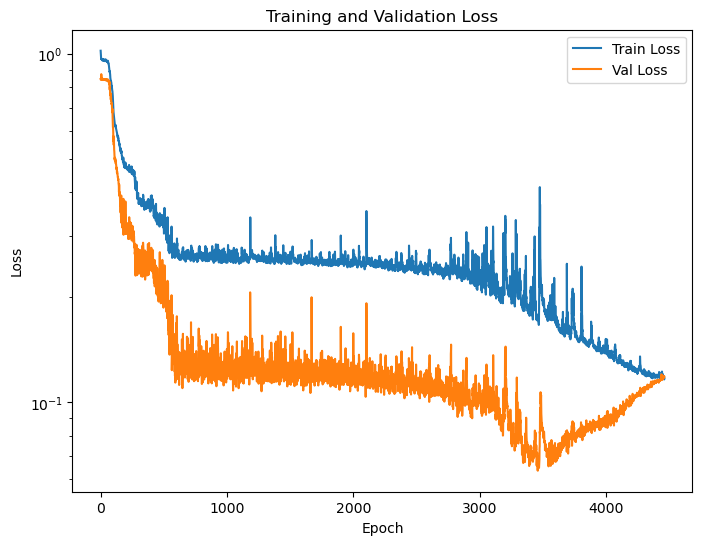

In [26]:
#Plot the training history
plt.figure(figsize=(8,6))
plt.plot(history['train'], label='Train Loss')
plt.plot(history['val'], label='Val Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

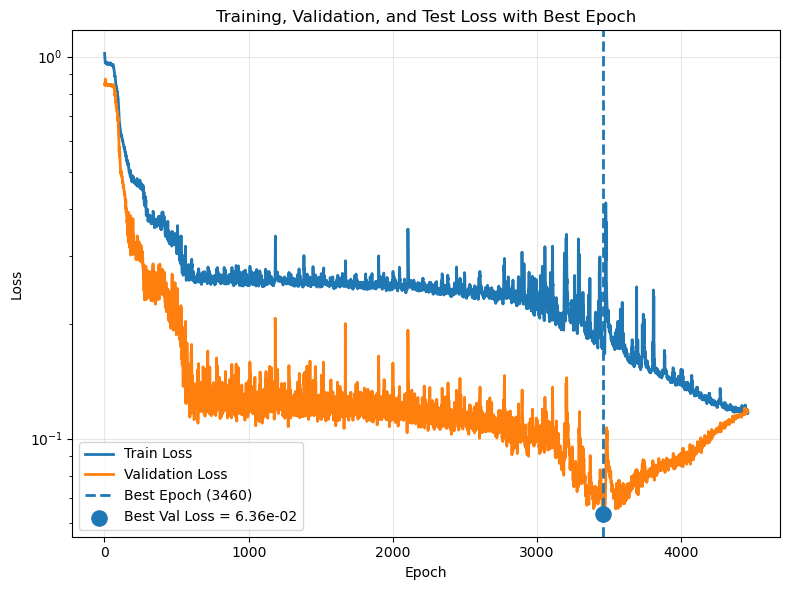

In [27]:
import matplotlib.pyplot as plt
import numpy as np

train_loss = history['train']
val_loss   = history['val']

epochs = np.arange(1, len(train_loss) + 1)

# ---- best epoch from validation ----
best_epoch = np.argmin(val_loss) + 1
best_val   = val_loss[best_epoch - 1]

plt.figure(figsize=(8, 6))

# Train & Validation
plt.plot(epochs, train_loss, label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)

# ---- Test loss handling ----
if 'test' in history:
    test_loss = history['test']

    # case 1: test loss per epoch
    if isinstance(test_loss, (list, np.ndarray)) and len(test_loss) == len(epochs):
        plt.plot(epochs, test_loss, label='Test Loss', linewidth=2)

    # case 2: single test loss value
    else:
        plt.scatter(
            best_epoch, test_loss,
            marker='*', s=200, label='Test Loss (Best Epoch)'
        )

# ---- Best epoch marker ----
plt.axvline(
    best_epoch, linestyle='--', linewidth=2,
    label=f'Best Epoch ({best_epoch})'
)
plt.scatter(
    best_epoch, best_val, s=120, zorder=5,
    label=f'Best Val Loss = {best_val:.2e}'
)

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training, Validation, and Test Loss with Best Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
print(history.keys())

dict_keys(['train', 'val'])


In [13]:
df['split'] = 'train'
df.loc[val_idx, 'split'] = 'val'
df.loc[test_idx, 'split'] = 'test'

NameError: name 'test_loss' is not defined

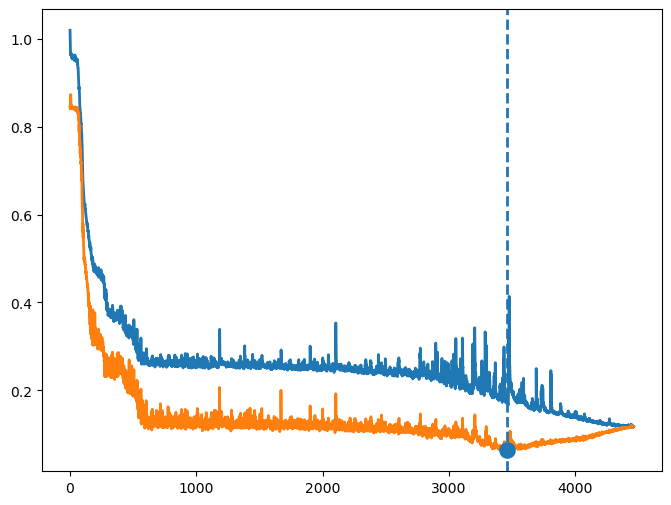

In [29]:
plt.figure(figsize=(8, 6))

plt.plot(epochs, train_loss, label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)

# ---- Best epoch ----
plt.axvline(best_epoch, linestyle='--', linewidth=2,
            label=f'Best Epoch ({best_epoch})')
plt.scatter(best_epoch, best_val, s=120, zorder=5,
            label=f'Best Val Loss = {best_val:.2e}')

# ---- Test loss (single point) ----
plt.scatter(
    best_epoch, test_loss,
    marker='*', s=200, color='red',
    label=f'Test Loss = {test_loss:.2e}'
)

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training, Validation, and Test Loss with Best Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
import matplotlib.pyplot as plt
import os

for k in sorted(df['k'].unique()):
    sub = df[df['k'] == k].sort_values('Eta')
    ri, m = Ec_map[int(k)]

    plt.figure(figsize=(9, 6))

    # ---- true data (scatter by split) ----
    plt.scatter(
        sub[sub['split']=='train']['Eta'],
        sub[sub['split']=='train']['Ecval'],
        c='tab:blue', label='Train (true)', s=35
    )
    plt.scatter(
        sub[sub['split']=='val']['Eta'],
        sub[sub['split']=='val']['Ecval'],
        c='tab:orange', label='Validation (true)', s=35
    )
    plt.scatter(
        sub[sub['split']=='test']['Eta'],
        sub[sub['split']=='test']['Ecval'],
        c='tab:green', label='Test (true)', s=35
    )

    # ---- best model prediction curve ----
    plt.plot(
        sub['Eta'],
        sub['p_Ecval'],
        'k--', linewidth=2, label='Best model prediction'
    )

    plt.title(f"k={int(k)}   Ri={ri}   M={m}")
    plt.xlabel("Eta")
    plt.ylabel("Ec")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    fname = f"curve_k{int(k)}_Ri{ri}_M{m}_splits.png"
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=300)
    plt.close()

print("Saved train/val/test + best-model plots in:", OUT_DIR)

Saved train/val/test + best-model plots in: Grad-3Ec-pinn-results


In [24]:
train_losses = []   # length = epochs
val_losses   = []
test_losses  = []   # optional; usually evaluated once or periodically

ValueError: min() arg is an empty sequence

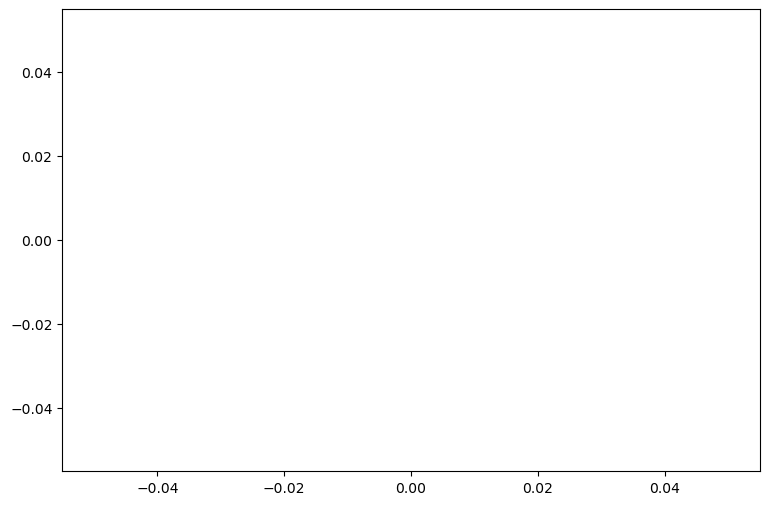

In [25]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(9, 6))

plt.plot(epochs, train_losses, label='Train Loss', linewidth=2)
plt.plot(epochs, val_losses, label='Validation Loss', linewidth=2)

# Plot test loss only if available per epoch
if 'test_losses' in globals():
    plt.plot(epochs, test_losses, label='Test Loss', linewidth=2)

# Mark best validation epoch
best_epoch = min(range(len(val_losses)), key=lambda i: val_losses[i]) + 1
plt.axvline(best_epoch, linestyle='--', label=f'Best Epoch ({best_epoch})')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training, Validation, and Test Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(9, 6))

plt.plot(epochs, train_losses, label='Train Loss', linewidth=2)
plt.plot(epochs, val_losses, label='Validation Loss', linewidth=2)

# Plot test loss only if available per epoch
if 'test_losses' in globals():
    plt.plot(epochs, test_losses, label='Test Loss', linewidth=2)

# Mark best validation epoch
best_epoch = min(range(len(val_losses)), key=lambda i: val_losses[i]) + 1
plt.axvline(best_epoch, linestyle='--', label=f'Best Epoch ({best_epoch})')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training, Validation, and Test Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'train_losses' is not defined

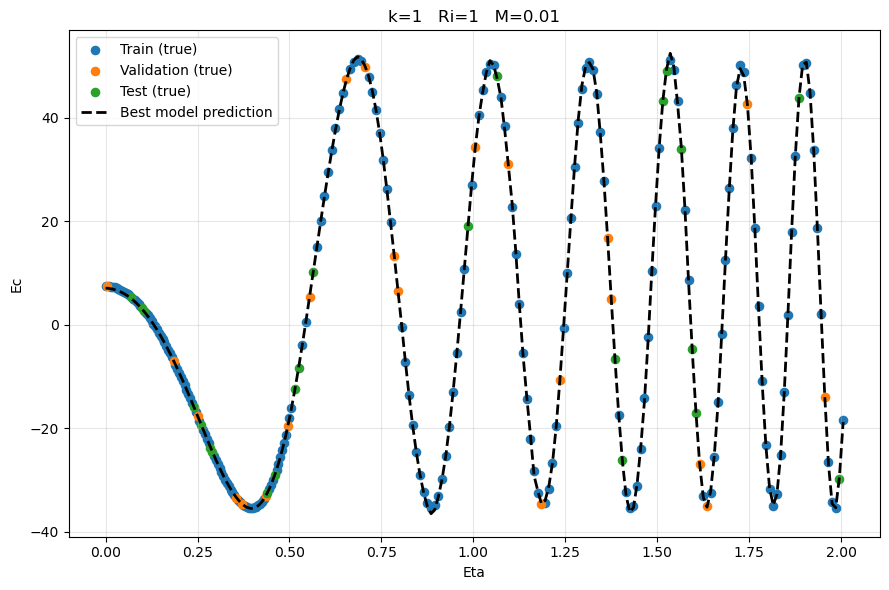

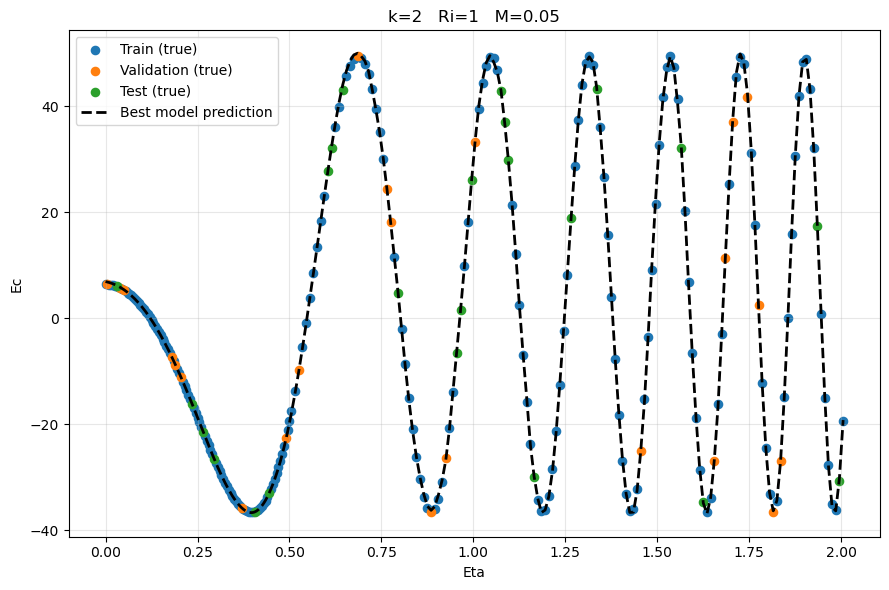

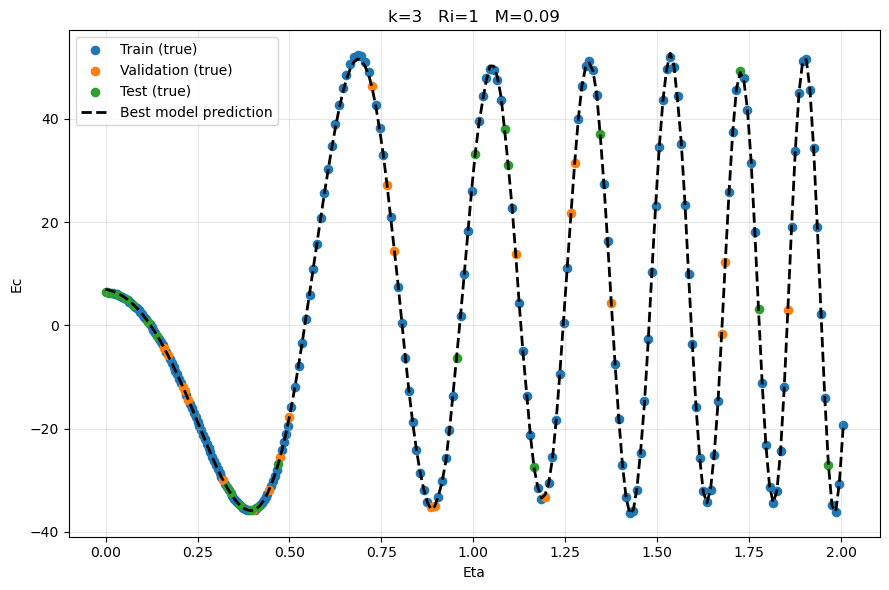

In [21]:
import matplotlib.pyplot as plt

for k in sorted(df['k'].unique()):
    sub = df[df['k'] == k].sort_values('Eta')
    ri, m = Ec_map[int(k)]

    plt.figure(figsize=(9, 6))

    # ---- true data (scatter by split) ----
    plt.scatter(
        sub[sub['split']=='train']['Eta'],
        sub[sub['split']=='train']['Ecval'],
        c='tab:blue', label='Train (true)', s=35
    )
    plt.scatter(
        sub[sub['split']=='val']['Eta'],
        sub[sub['split']=='val']['Ecval'],
        c='tab:orange', label='Validation (true)', s=35
    )
    plt.scatter(
        sub[sub['split']=='test']['Eta'],
        sub[sub['split']=='test']['Ecval'],
        c='tab:green', label='Test (true)', s=35
    )

    # ---- best model prediction curve ----
    plt.plot(
        sub['Eta'],
        sub['p_Ecval'],
        'k--', linewidth=2, label='Best model prediction'
    )

    plt.title(f"k={int(k)}   Ri={ri}   M={m}")
    plt.xlabel("Eta")
    plt.ylabel("Ec")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # ✅ Show in notebook
    plt.show()

    # ✅ Close AFTER showing (avoids memory leak)
    plt.close()

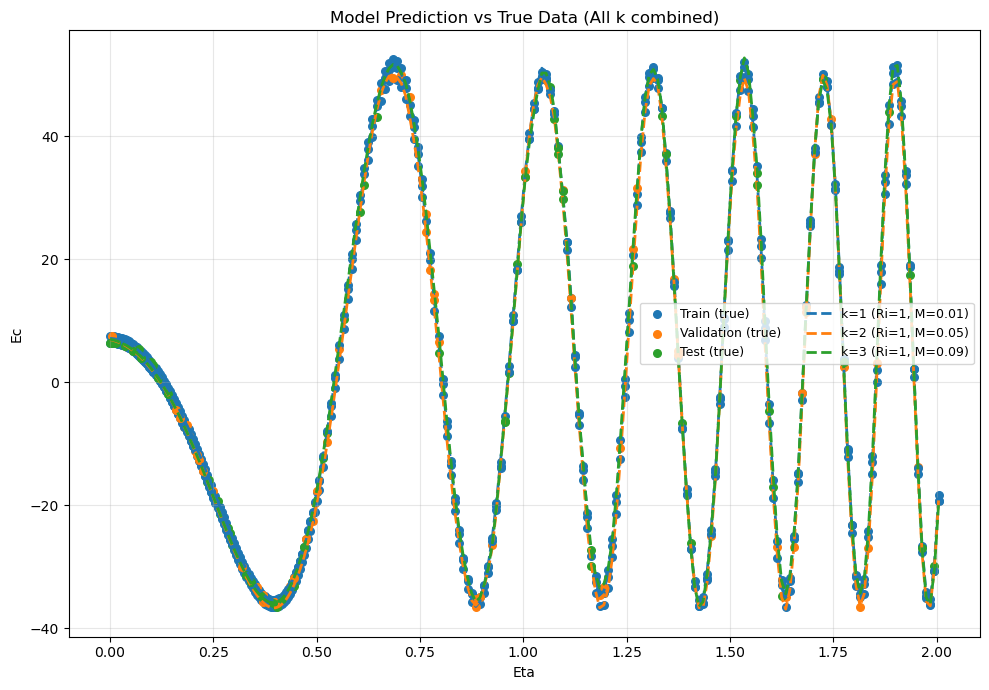

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Plot true data (only once in legend)
first = True

for k in sorted(df['k'].unique()):
    sub = df[df['k'] == k].sort_values('Eta')
    ri, m = Ec_map[int(k)]

    # ---- true data (scatter by split) ----
    plt.scatter(
        sub[sub['split']=='train']['Eta'],
        sub[sub['split']=='train']['Ecval'],
        c='tab:blue', s=30,
        label='Train (true)' if first else None
    )
    plt.scatter(
        sub[sub['split']=='val']['Eta'],
        sub[sub['split']=='val']['Ecval'],
        c='tab:orange', s=30,
        label='Validation (true)' if first else None
    )
    plt.scatter(
        sub[sub['split']=='test']['Eta'],
        sub[sub['split']=='test']['Ecval'],
        c='tab:green', s=30,
        label='Test (true)' if first else None
    )

    # ---- prediction curve (per k) ----
    plt.plot(
        sub['Eta'],
        sub['p_Ecval'],
        '--', linewidth=2,
        label=f"k={int(k)} (Ri={ri}, M={m})"
    )

    first = False

plt.xlabel("Eta")
plt.ylabel("Ec")
plt.title("Model Prediction vs True Data (All k combined)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# error = prediction - ground truth
df['error'] = df['p_Ecval'] - df['Ecval']

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

bins = 30

plt.hist(
    df[df['split']=='train']['error'],
    bins=bins, alpha=0.6, label='Train', density=True
)

plt.hist(
    df[df['split']=='val']['error'],
    bins=bins, alpha=0.6, label='Validation', density=True
)

plt.hist(
    df[df['split']=='test']['error'],
    bins=bins, alpha=0.6, label='Test', density=True
)

plt.axvline(0, linestyle='--', linewidth=2, label='Zero error')

plt.xlabel("Prediction Error (Ec_pred − Ec_true)")
plt.ylabel("Probability Density")
plt.title("Error Histogram (Train / Validation / Test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "error_histogram_splits.png"), dpi=300)
plt.show()
plt.close()

print("Saved error histogram in:", OUT_DIR)

In [16]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,4):
    sub = df[df['k']==k].sort_values('Eta')
    xi, ec = Ec_map[int(k)]
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Ecval'], mode='lines', name=f'Ec true Xi={xi} Ec={ec}'))
    
fig.update_layout(title='Ec value vs Eta for different Xi, Ec', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "Ec_values_plotly.html"))
fig.show()

In [17]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,4):
    sub = df[df['k']==k].sort_values('Eta')
    xi, ec = Ec_map[int(k)]
    
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Ecval'], mode='lines', name=f'F pred Xi={xi} Ec={ec}'))

fig.update_layout(title='Ec values vs Eta for different Xi, Ec', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "Ec_Pred_values_plotly.html"))
fig.show()

In [18]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()

for k in range(1,4):
    sub = df[df['k']==k].sort_values('Eta')
    xi, ec = Ec_map[int(k)]

    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Ecval'], mode='lines', name=f'Ec true Xi={xi} Ec={ec}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Ecval'], mode='markers', name=f'Ec pred Xi={xi} Ec={ec}'))
    
fig.update_layout(title='Ec values vs Eta for different Xi, Ec', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "Ec_Vs_Xi Pred_values_plotly.html"))
fig.show()